In [1]:
from skimage.filters import window
from skimage.registration import phase_cross_correlation

"""This Program is designed to simulated 2D lattices featuring noise, defects and blur. We will analyze the signals produced by these lattices using FFT, cross power spectrum, and phase correlation. We will aslo be testing different kinds of image processing techniques to see how it alters the data."""

'This Program is designed to simulated 2D lattices featuring noise, defects and blur. We will analyze the signals produced by these lattices using FFT, cross power spectrum, and phase correlation. We will aslo be testing different kinds of image processing techniques to see how it alters the data.'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [50]:
"""Develop lattice"""

N = 256
x = np.linspace(0, 10, N)
y = np.linspace(0, 10, N)
X, Y = np.meshgrid(x, y)

lattice = np.zeros((N,N))

spacing = 1.5
sigma = 0.15
y_spacing = spacing * np.sqrt(3)/2


# Create 8x8 grid of atoms with offset for HCP-like lattice
for i in np.arange(1,9):
    for j in np.arange(1,9):
        x_offset = (j % 2)* (spacing/2)
        lattice += np.exp(-((X - i*spacing-x_offset)**2 + (Y - j*y_spacing)**2)/(2*sigma**2)) # Create "Gaussian atoms" at each lattice site

In [51]:
# plt.imshow(lattice, cmap='viridis')
# plt.colorbar()

In [52]:
# Add Random noise (adjust to alter noise)
lattice += 0.1*np.random.rand(N,N)

# Add defect

lattice += 0.7 * np.exp(-((X-2.7)**2 + (Y-4.7)**2)/(2*sigma**2))
lattice += 0.65 * np.exp(-((X+4.5)**2 + (Y-3.23)**2)/(2*sigma**2))

# lattice += gaussian_filter(lattice, sigma=1)

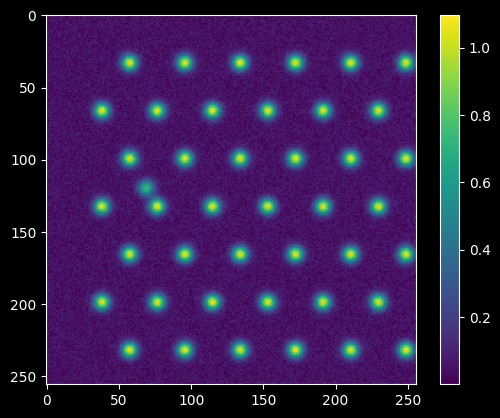

In [53]:
plt.imshow(lattice, cmap='viridis')
plt.colorbar()

In [54]:
# Subtract background w.r.t polynomial fitting of surface

def subtract_background(data):

    if data.ndim == 1:
        x = np.arange(len(data))
        coeffs = np.polyfit(x, data, 1)
        background = np.polyval(coeffs, x)
        return data - background

    elif data.ndim == 2:
        background_removed = np.zeros_like(data)
        for i, row in enumerate(data):
            x = np.arange(len(row))
            coeffs = np.polyfit(x, row, 1)
            background = np.polyval(coeffs, x)
            background_removed[i] = row - background
        return background_removed

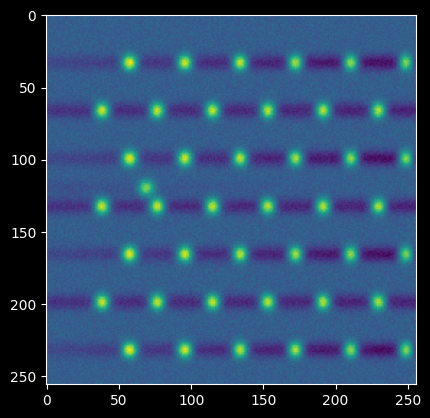

In [55]:
sub_lattice = subtract_background(lattice)
plt.imshow(sub_lattice, cmap='viridis')

In [56]:
# Create shifted lattice based off of same parameters as original lattice
dx = 0.35
dy= -0.25

shifted = np.zeros_like(lattice)

for i in np.arange(1,9):
    for j in np.arange(1,9):
        x_offset = (j % 2)* (spacing/2)
        shifted +=  np.exp(-((X - i*spacing - dx-x_offset)**2 +
                            (Y - j*y_spacing - dy)**2)/(2*sigma**2))

In [57]:
# plt.imshow(shifted_lattice, cmap='viridis')

In [58]:
# Add noise to shifted_lattice

shifted += 0.1*np.random.rand(N,N)

# Add Defect

# shifted += 0.5 * np.exp(-((X-3.7-dx)**2+(Y-6.2-dy)**2)/0.05)
shifted += 0.7 * np.exp(-((X-2.7-dx)**2 + (Y-4.7-dy)**2)/(2*sigma**2))
shifted += 0.65 * np.exp(-((X+4.5-dx)**2 + (Y-3.23-dy)**2)/(2*sigma**2))

# shifted += gaussian_filter(shifted, sigma=1)

In [59]:
# plt.imshow(shifted, cmap='viridis')

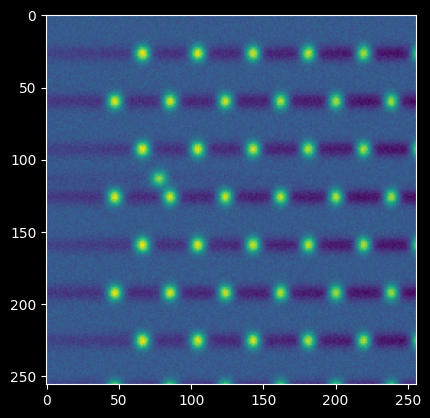

In [60]:
sub_shifted = subtract_background(shifted)
plt.imshow(sub_shifted, cmap='viridis')

In [61]:
def hanning(N):
    h = np.hanning(N)
    return np.outer(h,h)

window = hanning(N)

f1 = np.fft.fft2(sub_lattice*window)
f2 = np.fft.fft2(sub_shifted*window)

# f1 = np.fft.fft2(lattice*window)
# f2 = np.fft.fft2(shifted*window)


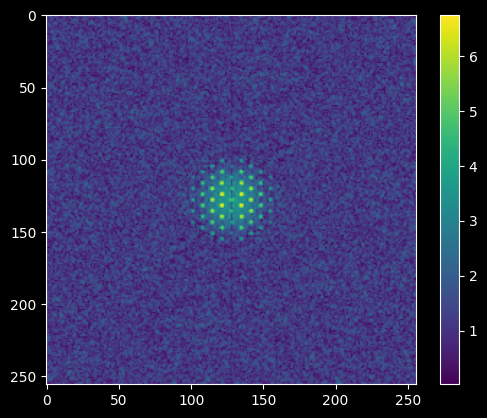

In [62]:
plt.imshow(np.log1p(np.abs(np.fft.fftshift(f1))), cmap='viridis')
plt.colorbar()

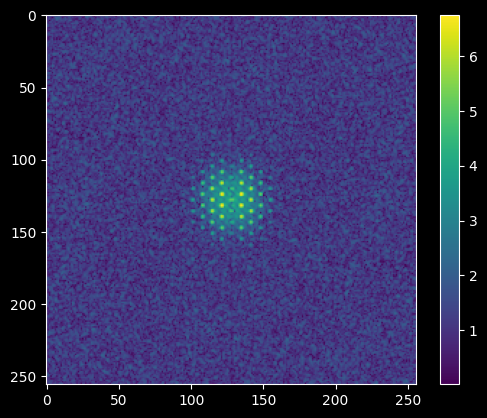

In [63]:
plt.imshow(np.log1p(np.abs(np.fft.fftshift(f2))), cmap='viridis')
plt.colorbar()

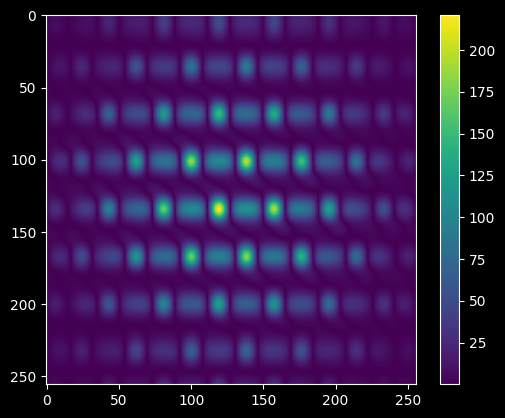

In [64]:
# cross power spectrum
# sub_f1 = subtract_background(f1)
# sub_f2 = subtract_background(f2)

cross = np.fft.ifft2(f1 * np.conj(f2))
cross = np.abs(np.fft.fftshift(cross))

plt.imshow(cross, cmap='viridis')
plt.colorbar()

In [65]:
cross_power= f1*np.conj(f2)
phase_correlation = cross_power/(np.abs(cross_power)+1e-10)
R = np.fft.ifft2(phase_correlation)

phase = np.abs(np.fft.fftshift(R))

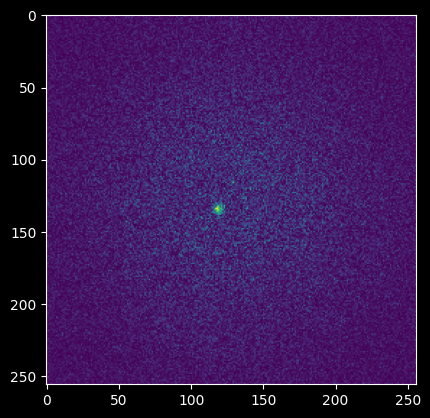

In [66]:
plt.imshow(phase, cmap='viridis')

In [67]:
# determine the pixel size

pixel_size = x[1] - x[0]
print(f"Pixel size: {pixel_size:.4f}")
print(f"dx in pixels: {dx/pixel_size:.1f}")
print(f"dy in pixels: {dy/pixel_size:.1f}")

Pixel size: 0.0392
dx in pixels: 8.9
dy in pixels: -6.4


In [68]:
# find the peak in order to determine drift values
peak = np.unravel_index(np.argmax(phase), phase.shape)
center = np.array(phase.shape)//2
drift = np.array(peak)- center



In [69]:
dx = drift[0]*(x[1] - x[0])
dy = drift[1]*(y[1] - y[0])
print(f"Drift in x: {dx}")
print(f"Drift in y: {dy}")

Drift in x: 0.23529411764705882
Drift in y: -0.39215686274509803


In [70]:
y_max, x_max = np.unravel_index(np.argmax(phase), phase.shape)

In [71]:
h,w = lattice.shape

y_center = h // 2
x_center = w // 2
y_min = max(y_max - 1, 0)
y_max_p = min(y_max + 2, h)
x_min = max(x_max - 1, 0)
x_max_p = min(x_max + 2, w)
region = phase[y_min:y_max_p, x_min:x_max_p]
# Calculate center of mass
total_mass = np.sum(region)
# Initialize grid coordinates
y_coords, x_coords = np.mgrid[y_min:y_max_p, x_min:x_max_p]
# Calculate weighted average for subpixel accuracy
y_refined = np.sum(y_coords * region) / total_mass
x_refined = np.sum(x_coords * region) / total_mass
# Calculate shift from center (origin)
y_shift = -(y_refined - y_center)
x_shift = -(x_refined - x_center)

print(y_shift, x_shift)


-6.057953188222285 9.925295781241005


In [72]:
dx_prime = x_shift*(x[1]-x[0])
dy_prime = y_shift*(y[1]-y[0])

print(dx_prime, dy_prime)

0.38922728553886293 -0.23756679169499156


In [73]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

# -------------------------------
# SURFACE MODELS
# -------------------------------

def plane(coords, a, b, c):
    x, y = coords
    return a*x + b*y + c

def poly(coords, a, b, c, d, e, f):
    x, y = coords
    return a*x**2 + b*y**2 + c*x*y + d*x + e*y + f


# -------------------------------
# FITTING FUNCTIONS
# -------------------------------

def fit_surface(img, func, p0, mask=None):
    """
    Generic surface fitting routine.
    Used for both plane and polynomial fits.
    """

    # Create coordinate grid
    y = np.arange(img.shape[0])
    x = np.arange(img.shape[1])
    X, Y = np.meshgrid(x, y)

    # Flatten
    if mask is None:
        x_flat = X.flatten()
        y_flat = Y.flatten()
        z_flat = img.flatten()
    else:
        x_flat = X[mask == 1]
        y_flat = Y[mask == 1]
        z_flat = img[mask == 1]

    # Fit
    params, _ = curve_fit(func, (x_flat, y_flat), z_flat, p0)

    fitted_surface = func((X, Y), *params).reshape(img.shape)

    corr, _ = pearsonr(z_flat, func((x_flat, y_flat), *params))

    return fitted_surface, params, corr


def FitPlane(img, mask=None):
    return fit_surface(img, plane, np.zeros(3), mask)


def FitPoly(img, mask=None):
    return fit_surface(img, poly, np.zeros(6), mask)


# -------------------------------
# LINE OFFSET CORRECTION
# -------------------------------

def remove_line_offsets(img, mask=None):
    """
    Removes scan-line creep / slow drift between rows.
    """

    corrected = img.copy()

    for i in range(1, img.shape[0]):

        prev = corrected[i-1]
        curr = corrected[i]

        if mask is not None:
            prev = prev[mask[i] == 1]
            curr = curr[mask[i] == 1]

        offset = np.median(curr - prev) if len(curr) > 0 else 0
        corrected[i] -= offset

    return corrected


# -------------------------------
# MASTER PIPELINE
# -------------------------------

def flatten_image(img, mask=None,
                  remove_poly=False,
                  remove_plane=True,
                  remove_lines=False):
    """
    Full physically-ordered flattening pipeline.
    """

    result = img.astype(float).copy()

    # STEP 1 — Remove scanner bow (Polynomial)
    if remove_poly:
        poly_surface, _, _ = FitPoly(result, mask)
        result -= poly_surface

    # STEP 2 — Remove tilt (Plane)
    if remove_plane:
        plane_surface, _, _ = FitPlane(result, mask)
        result -= plane_surface

    # STEP 3 — Remove scan creep (Line offsets)
    if remove_lines:
        result = remove_line_offsets(result, mask)

    return result

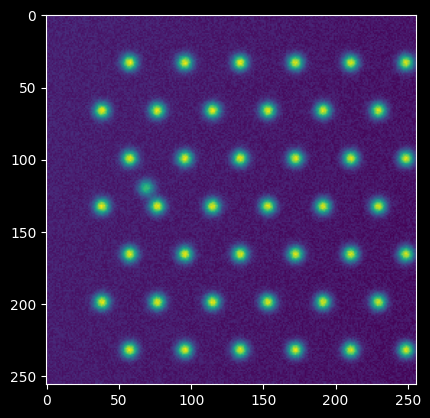

In [74]:
plt.imshow(flatten_image(lattice, mask=None, remove_poly= False))

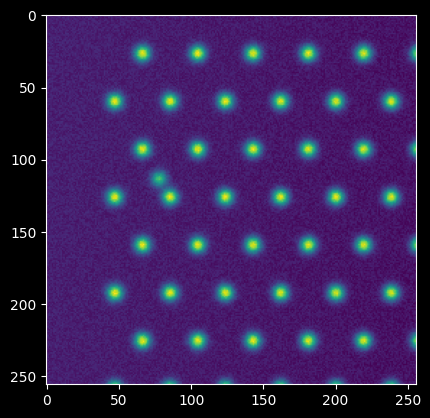

In [75]:
plt.imshow(flatten_image(shifted, mask=None))

In [76]:
fitted_lattice = flatten_image(lattice, mask=None, remove_poly=True)
fitted_shifted= flatten_image(shifted, mask=None, remove_poly=True)


f1_fit = np.fft.fft2(fitted_lattice)
f2_fit = np.fft.fft2(fitted_shifted)

f1_fit_window = window * f1_fit
f2_fit_window = window* f2_fit

cross = f1_fit_window * np.conj(f2_fit_window)


C:\Users\conno.DESKTOP-98EBONR\AppData\Local\Temp\ipykernel_60768\2422396530.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(z_flat, func((x_flat, y_flat), *params))


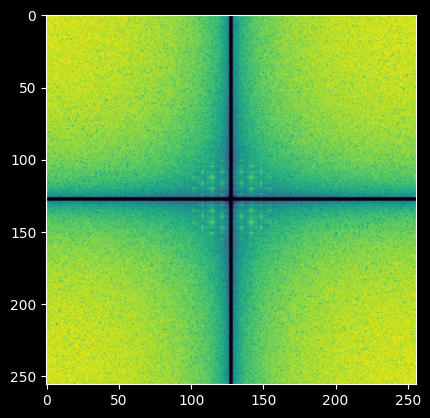

In [77]:
plt.imshow(np.log10(np.abs(np.fft.fftshift(f1_fit_window))), cmap = "viridis")

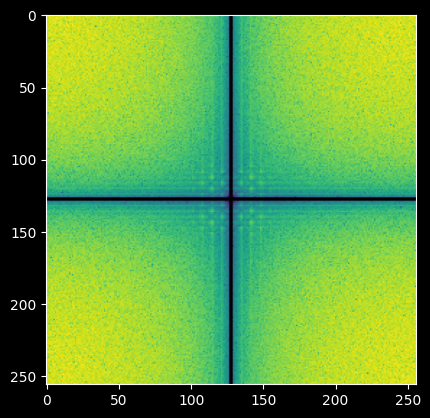

In [78]:
plt.imshow(np.log10(np.abs(np.fft.fftshift(f2_fit_window))), cmap = "viridis")

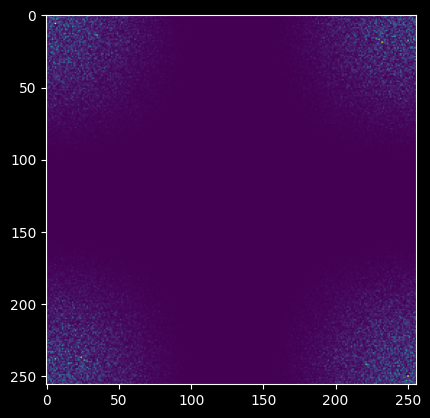

In [79]:
plt.imshow(np.abs(np.fft.fftshift(cross)), cmap = "viridis")